# Multi-Branch Facial Component Recognition
This notebook processes facial images using MediaPipe to extract specific components (eyes, nose, lips, whole face) and evaluates their individual and combined predictive power using PyTorch and ResNet-18.

In [1]:
import os
import cv2
import urllib.request
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

# 1. Setup Local Relative Paths
INPUT_DIR = "./CFD"  # Place raw images here if running extraction
OUTPUT_DIR = "./processed_cfd_components"

FOR_EYES = os.path.join(OUTPUT_DIR, "eyes")
FOR_NOSE = os.path.join(OUTPUT_DIR, "nose")
FOR_LIPS = os.path.join(OUTPUT_DIR, "lips")
FOR_WHOLE_FACE = os.path.join(OUTPUT_DIR, "whole_face")

for directory in [FOR_EYES, FOR_NOSE, FOR_LIPS, FOR_WHOLE_FACE]:
    os.makedirs(directory, exist_ok=True)

# 2. Download MediaPipe Model locally if missing
MODEL_PATH = './face_landmarker.task'
if not os.path.exists(MODEL_PATH):
    print("Downloading MediaPipe Face Landmarker model...")
    url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task"
    urllib.request.urlretrieve(url, MODEL_PATH)
    print("Download complete.")

In [2]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5
)
face_landmarker = vision.FaceLandmarker.create_from_options(options)

EYE_LANDMARKS = [33, 246, 161, 160, 159, 158, 157, 173, 133, 155, 154, 153, 145, 144, 163, 7, 362, 398, 384, 385, 386, 387, 388, 466, 263, 249, 390, 373, 374, 380, 381, 382]
NOSE_LANDMARKS = [1, 2, 98, 327, 168, 6, 197, 195, 5, 4, 129, 358, 275, 45, 220, 115, 344, 440, 274, 275]
LIP_LANDMARKS = [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 185, 40, 39, 37, 0, 267, 269, 270, 409]

def extract_padded_feature(image, face_landmarks, landmark_indices=None, is_whole_face=False, target_size=(64, 64), margin=15):
    h, w, _ = image.shape
    if is_whole_face:
        x_coords = [int(lm.x * w) for lm in face_landmarks]
        y_coords = [int(lm.y * h) for lm in face_landmarks]
    else:
        x_coords = [int(face_landmarks[idx].x * w) for idx in landmark_indices]
        y_coords = [int(face_landmarks[idx].y * h) for idx in landmark_indices]

    if not x_coords or not y_coords: return None

    xmin, xmax = min(x_coords), max(x_coords)
    ymin, ymax = min(y_coords), max(y_coords)

    if is_whole_face:
        xmin, xmax = max(0, xmin - margin), min(w, xmax + margin)
        ymin, ymax = max(0, ymin - (margin + 20)), min(h, ymax + margin)
    else:
        xmin, xmax = max(0, xmin - margin), min(w, xmax + margin)
        ymin, ymax = max(0, ymin - margin), min(h, ymax + margin)

    crop_w, crop_h = xmax - xmin, ymax - ymin
    if crop_w <= 0 or crop_h <= 0: return None

    raw_crop = image[ymin:ymax, xmin:xmax]
    max_side = max(crop_w, crop_h)

    square_crop = np.zeros((max_side, max_side, 3), dtype=np.uint8)
    x_offset, y_offset = (max_side - crop_w) // 2, (max_side - crop_h) // 2
    square_crop[y_offset:y_offset+crop_h, x_offset:x_offset+crop_w] = raw_crop

    return cv2.resize(square_crop, target_size, interpolation=cv2.INTER_AREA)

In [ ]:
# DATA EXTRACTION PIPELINE
# Run this cell ONLY if you need to regenerate the dataset from the raw CFD images
# Ensure your raw dataset is located in a folder named 'CFD' next to this notebook


INPUT_DIR = "./CFD"

if not os.path.exists(INPUT_DIR):
    print(f"Skipping extraction: The raw image folder '{INPUT_DIR}' was not found.")
    print("Assuming processed_cfd_components are already extracted from backup.")
else:
    all_images = [os.path.join(root, f) for root, dirs, files in os.walk(INPUT_DIR) 
                  for f in files if f.endswith(('.png', '.jpg', '.jpeg')) and f.startswith('CFD-')]

    print(f"Found {len(all_images)} raw images. Beginning facial component extraction...")

    for img_path in tqdm(all_images):
        img_name = os.path.basename(img_path)
        parts = img_name.split('-')
        
        # Ensure strict naming convention matching
        if len(parts) < 3: continue
        identity = f"{parts[0]}-{parts[1]}-{parts[2]}"
        
        # Create identity-specific subfolders for the multi-branch network
        for d in [FOR_EYES, FOR_NOSE, FOR_LIPS]: 
            os.makedirs(os.path.join(d, identity), exist_ok=True)
            
        image = cv2.imread(img_path)
        if image is None: continue
            
        # Convert to RGB for MediaPipe processing
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        detection_result = face_landmarker.detect(mp_image)
        
        if not detection_result.face_landmarks: continue
            
        landmarks = detection_result.face_landmarks[0]
        
        # Extract individual geometries with strict pixel margins
        eye_crop = extract_padded_feature(image, landmarks, EYE_LANDMARKS, margin=25)
        nose_crop = extract_padded_feature(image, landmarks, NOSE_LANDMARKS, margin=15)
        lip_crop = extract_padded_feature(image, landmarks, LIP_LANDMARKS, margin=15)
        whole_face_crop = extract_padded_feature(image, landmarks, is_whole_face=True, target_size=(224, 224), margin=40)
        
        # Save crops to local disk
        if eye_crop is not None: cv2.imwrite(os.path.join(FOR_EYES, identity, img_name), eye_crop)
        if nose_crop is not None: cv2.imwrite(os.path.join(FOR_NOSE, identity, img_name), nose_crop)
        if lip_crop is not None: cv2.imwrite(os.path.join(FOR_LIPS, identity, img_name), lip_crop)
        if whole_face_crop is not None: cv2.imwrite(os.path.join(FOR_WHOLE_FACE, img_name), whole_face_crop)

    print("Data engineering complete. All spatial components successfully isolated and saved.")

'\nINPUT_DIR = "./CFD"\n\nif not os.path.exists(INPUT_DIR):\n    print(f"Skipping extraction: The raw image folder \'{INPUT_DIR}\' was not found.")\n    print("Assuming processed_cfd_components are already extracted from backup.")\nelse:\n    all_images = [os.path.join(root, f) for root, dirs, files in os.walk(INPUT_DIR) \n                  for f in files if f.endswith((\'.png\', \'.jpg\', \'.jpeg\')) and f.startswith(\'CFD-\')]\n\n    print(f"Found {len(all_images)} raw images. Beginning facial component extraction...")\n\n    for img_path in tqdm(all_images):\n        img_name = os.path.basename(img_path)\n        parts = img_name.split(\'-\')\n\n        # Ensure strict naming convention matching\n        if len(parts) < 3: continue\n        identity = f"{parts[0]}-{parts[1]}-{parts[2]}"\n\n        # Create identity-specific subfolders for the multi-branch network\n        for d in [FOR_EYES, FOR_NOSE, FOR_LIPS]: \n            os.makedirs(os.path.join(d, identity), exist_ok=True)\n\n

In [4]:
class CFD_WholeFace_Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

        identities = set()
        for f in self.image_files:
            parts = f.split('-')
            if len(parts) >= 3:
                identities.add(f"{parts[0]}-{parts[1]}-{parts[2]}")

        self.identities = sorted(list(identities))
        self.id_to_label = {identity: idx for idx, identity in enumerate(self.identities)}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        parts = img_name.split('-')
        identity = f"{parts[0]}-{parts[1]}-{parts[2]}"
        label = self.id_to_label[identity]

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

baseline_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

try:
    baseline_dataset = CFD_WholeFace_Dataset(root_dir=FOR_WHOLE_FACE, transform=baseline_transforms)
    num_classes = len(baseline_dataset.identities)
    total_size = len(baseline_dataset)
    train_size = int(0.8 * total_size)
    val_size = total_size - train_size

    train_dataset, val_dataset = random_split(baseline_dataset, [train_size, val_size])
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    baseline_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    num_ftrs = baseline_model.fc.in_features
    baseline_model.fc = nn.Linear(num_ftrs, num_classes)
    baseline_model = baseline_model.to(device)

    print(f"Dataset split: {train_size} training images, {val_size} validation images.")
    print(f"Network configured to recognize {num_classes} unique identities on {device.type.upper()}.")
except FileNotFoundError:
    print(f"Please ensure the {FOR_WHOLE_FACE} directory exists and contains images.")

Dataset split: 965 training images, 242 validation images.
Network configured to recognize 597 unique identities on CPU.


1. Baseline Whole-Face Model Validation

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(baseline_model.parameters(), lr=0.01, momentum=0.9)
EPOCHS = 50

print("Initializing baseline training and validation...")
for epoch in range(EPOCHS):
    baseline_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = baseline_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    baseline_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = baseline_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print("\nBaseline Training and Validation Complete.")

Initializing baseline training and validation...
Epoch [05/50] | Train Loss: 1.5019 | Train Acc: 76.06% | Val Acc: 60.33%
Epoch [10/50] | Train Loss: 0.1089 | Train Acc: 99.79% | Val Acc: 61.16%
Epoch [15/50] | Train Loss: 0.0431 | Train Acc: 99.79% | Val Acc: 60.33%
Epoch [20/50] | Train Loss: 0.0258 | Train Acc: 100.00% | Val Acc: 61.57%
Epoch [25/50] | Train Loss: 0.0202 | Train Acc: 99.90% | Val Acc: 60.74%
Epoch [30/50] | Train Loss: 0.0169 | Train Acc: 100.00% | Val Acc: 61.57%
Epoch [35/50] | Train Loss: 0.0241 | Train Acc: 100.00% | Val Acc: 59.92%
Epoch [40/50] | Train Loss: 0.0167 | Train Acc: 100.00% | Val Acc: 60.74%
Epoch [45/50] | Train Loss: 0.0089 | Train Acc: 100.00% | Val Acc: 61.16%
Epoch [50/50] | Train Loss: 0.0074 | Train Acc: 100.00% | Val Acc: 61.57%

Baseline Training and Validation Complete.


In [6]:
class MultiBranchCFDDataset(Dataset):
    def __init__(self, base_dir, transform=None):
        self.base_dir = base_dir
        self.transform = transform
        self.eyes_dir = os.path.join(base_dir, 'eyes')
        self.nose_dir = os.path.join(base_dir, 'nose')
        self.lips_dir = os.path.join(base_dir, 'lips')
        
        self.samples = []
        if not os.path.exists(self.eyes_dir):
            raise FileNotFoundError(f"Missing folder: {self.eyes_dir}. Make sure processed_cfd_components is in the same directory.")
            
        self.identities = sorted(os.listdir(self.eyes_dir))
        self.id_to_label = {identity: idx for idx, identity in enumerate(self.identities)}
        
        for identity in self.identities:
            identity_dir = os.path.join(self.eyes_dir, identity)
            if not os.path.isdir(identity_dir): continue
            for img_name in os.listdir(identity_dir):
                if img_name.endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((identity, img_name))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        identity, img_name = self.samples[idx]
        label = self.id_to_label[identity]
        
        eye_path = os.path.join(self.eyes_dir, identity, img_name)
        nose_path = os.path.join(self.nose_dir, identity, img_name)
        lip_path = os.path.join(self.lips_dir, identity, img_name)
        
        eye_img = Image.open(eye_path).convert('RGB')
        nose_img = Image.open(nose_path).convert('RGB')
        lip_img = Image.open(lip_path).convert('RGB')
        
        if self.transform:
            eye_img = self.transform(eye_img)
            nose_img = self.transform(nose_img)
            lip_img = self.transform(lip_img)
            
        return eye_img, nose_img, lip_img, torch.tensor(label, dtype=torch.long)

mb_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

try:
    mb_dataset = MultiBranchCFDDataset(base_dir=OUTPUT_DIR, transform=mb_transforms)
    train_size = int(0.8 * len(mb_dataset))
    val_size = len(mb_dataset) - train_size
    train_dataset, val_dataset = random_split(mb_dataset, [train_size, val_size])

    mb_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    mb_val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    print("Multi-branch DataLoader initialized successfully.")
except FileNotFoundError as e:
    print(e)

Multi-branch DataLoader initialized successfully.


2. Multi-Branch Architecture Setup

In [7]:
class FlexibleMultiBranchResNet(nn.Module):
    def __init__(self, num_classes, enabled_branches):
        super(FlexibleMultiBranchResNet, self).__init__()
        self.enabled_branches = enabled_branches
        
        # Ensures fixed-size output regardless of patch variations
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        if 'eyes' in enabled_branches:
            self.branch_eye = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            self.branch_eye.fc = nn.Identity()
        if 'nose' in enabled_branches:
            self.branch_nose = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            self.branch_nose.fc = nn.Identity()
        if 'lips' in enabled_branches:
            self.branch_lip = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            self.branch_lip.fc = nn.Identity()

        # Concatenates 512 features from each branch
        input_dim = 512 * len(enabled_branches)

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, eye, nose, lip):
        features = []
        if 'eyes' in self.enabled_branches:
            f = self.branch_eye(eye)
            features.append(self.pool(f.view(f.size(0), 512, 1, 1)).view(f.size(0), -1))
        if 'nose' in self.enabled_branches:
            f = self.branch_nose(nose)
            features.append(self.pool(f.view(f.size(0), 512, 1, 1)).view(f.size(0), -1))
        if 'lips' in self.enabled_branches:
            f = self.branch_lip(lip)
            features.append(self.pool(f.view(f.size(0), 512, 1, 1)).view(f.size(0), -1))

        combined = torch.cat(features, dim=1)
        return self.classifier(combined)

print("Flexible multi-branch engine successfully compiled.")

Flexible multi-branch engine successfully compiled.


In [8]:
def train_and_evaluate_combination(combination_names, train_loader, val_loader, num_classes, device, epochs=10):
    print(f"\n==================================================")
    print(f" TRAINING COMBINATION: {' + '.join(combination_names).upper()}")
    print(f"==================================================")

    model = FlexibleMultiBranchResNet(num_classes=num_classes, enabled_branches=combination_names).to(device)
    criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for eyes, noses, lips, labels in train_loader:
            eyes, noses, lips, labels = eyes.to(device), noses.to(device), lips.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(eyes, noses, lips)
            loss = criterion(outputs, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        scheduler.step()

        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for eyes, noses, lips, labels in val_loader:
                eyes, noses, lips, labels = eyes.to(device), noses.to(device), lips.to(device), labels.to(device)
                outputs = model(eyes, noses, lips)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc

        current_lr = scheduler.get_last_lr()[0]
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1:02d}/{epochs}] | LR: {current_lr:.6f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    print(f"\n>>> Peak Validation Accuracy for {'+'.join(combination_names)}: {best_val_acc:.2f}%")
    return best_val_acc

3. Experimental Grid Search (50 Epochs)

In [9]:
experiments = [
    ['eyes'],
    ['nose'],
    ['lips'],
    ['eyes', 'nose'],
    ['nose', 'lips'],
    ['eyes', 'lips'],
    ['eyes', 'nose', 'lips']
]

results_grid = {}

for combo in experiments:
    combo_label = "-".join(combo)
    peak_accuracy = train_and_evaluate_combination(
        combination_names=combo,
        train_loader=mb_train_loader,
        val_loader=mb_val_loader,
        num_classes=num_classes,
        device=device,
        epochs=50
    )
    results_grid[combo_label] = peak_accuracy




 TRAINING COMBINATION: EYES
Epoch [05/50] | LR: 0.010000 | Train Acc: 5.80% | Val Acc: 0.41%
Epoch [10/50] | LR: 0.010000 | Train Acc: 22.59% | Val Acc: 5.37%
Epoch [15/50] | LR: 0.005000 | Train Acc: 43.42% | Val Acc: 14.46%
Epoch [20/50] | LR: 0.005000 | Train Acc: 54.40% | Val Acc: 22.31%
Epoch [25/50] | LR: 0.005000 | Train Acc: 58.96% | Val Acc: 26.86%
Epoch [30/50] | LR: 0.002500 | Train Acc: 62.18% | Val Acc: 32.64%
Epoch [35/50] | LR: 0.002500 | Train Acc: 63.32% | Val Acc: 37.19%
Epoch [40/50] | LR: 0.002500 | Train Acc: 63.63% | Val Acc: 39.26%
Epoch [45/50] | LR: 0.001250 | Train Acc: 64.25% | Val Acc: 39.26%
Epoch [50/50] | LR: 0.001250 | Train Acc: 64.04% | Val Acc: 41.74%

>>> Peak Validation Accuracy for eyes: 41.74%

 TRAINING COMBINATION: NOSE
Epoch [05/50] | LR: 0.010000 | Train Acc: 8.60% | Val Acc: 0.00%
Epoch [10/50] | LR: 0.010000 | Train Acc: 31.40% | Val Acc: 6.20%
Epoch [15/50] | LR: 0.005000 | Train Acc: 50.26% | Val Acc: 21.49%
Epoch [20/50] | LR: 0.005000 |


             FINAL EXPERIMENT RESULTS             
Component Combination  Peak Validation Accuracy
                 nose                 52.892562
            eyes-nose                 48.760331
       eyes-nose-lips                 45.867769
                 eyes                 41.735537
            nose-lips                 40.495868
            eyes-lips                 35.537190
                 lips                 15.702479


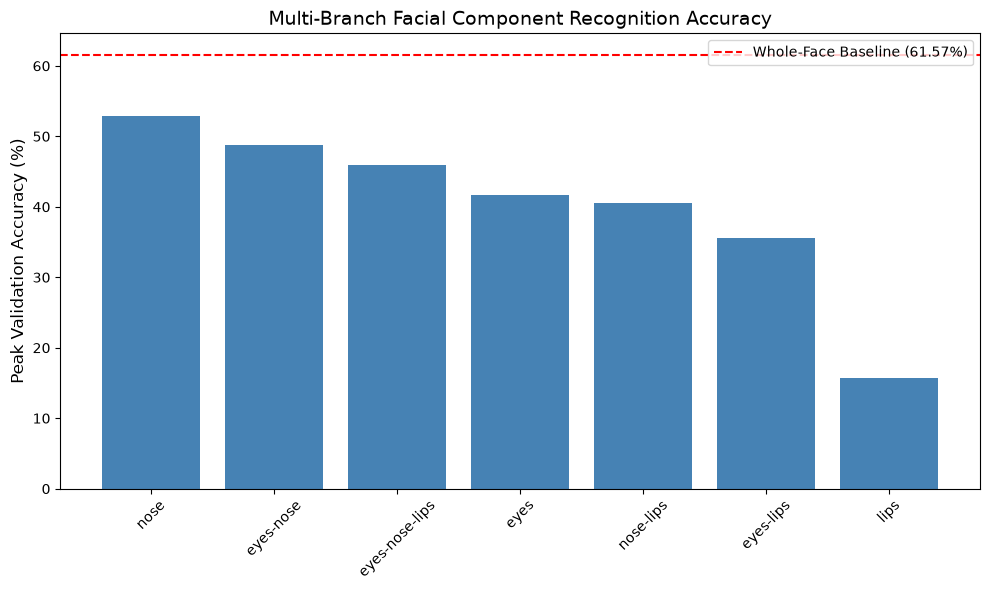

In [12]:
print("\n==================================================")
print("             FINAL EXPERIMENT RESULTS             ")
print("==================================================")
df_results = pd.DataFrame(list(results_grid.items()), columns=['Component Combination', 'Peak Validation Accuracy'])

df_results = df_results.sort_values(by='Peak Validation Accuracy', ascending=False)
print(df_results.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.bar(df_results['Component Combination'], df_results['Peak Validation Accuracy'], color='steelblue')
plt.axhline(y=61.57, color='red', linestyle='--', label='Whole-Face Baseline (61.57%)') # Adding your baseline for comparison
plt.title('Multi-Branch Facial Component Recognition Accuracy', fontsize=14)
plt.ylabel('Peak Validation Accuracy (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()